In [4]:
from PIL import Image
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'
 
import torch
from torch import nn
from torchvision.models import resnet50
import torchvision.transforms as T
torch.set_grad_enabled(False);

In [5]:
# Fix OpenMP library conflict that causes kernel crashes
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'


In [6]:
# Custom classes for dog/cat detection
CLASSES = [
    'N/A', 'cat', 'dog'
]
 
# colors for visualization, you can use your own colors here
COLORS = [[0.000, 0.447, 0.741], [0.850, 0.325, 0.098], [0.929, 0.694, 0.125],
          [0.494, 0.184, 0.556], [0.466, 0.674, 0.188], [0.301, 0.745, 0.933]]

In [22]:
# standard PyTorch mean-std input image normalization
transform = T.Compose([
    T.Resize(1200), # resize image, you can adjust this value 
    T.ToTensor(), # convert to tensor
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # normalize image
])
 

In [18]:
# for output bounding box post-processing
def box_cxcywh_to_xyxy(x):
    x_c, y_c, w, h = x.unbind(1)
    b = [(x_c - 0.5 * w), (y_c - 0.5 * h),
         (x_c + 0.5 * w), (y_c + 0.5 * h)]
    return torch.stack(b, dim=1)
 
# Function to rescale bounding boxes to the original image size
def rescale_bboxes(out_bbox, size):
    img_w, img_h = size
    b = box_cxcywh_to_xyxy(out_bbox)
    b = b * torch.tensor([img_w, img_h, img_w, img_h], dtype=torch.float32)
    return b

In [19]:
# Function to plot results
def plot_results(pil_img, prob, boxes):
    plt.figure(figsize=(12,8))
    plt.imshow(pil_img)
    ax = plt.gca()
    colors = COLORS * 100
    for p, (xmin, ymin, xmax, ymax), c in zip(prob, boxes.tolist(), colors):
        ax.add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                   fill=False, color=c, linewidth=3))
        cl = p.argmax()
        text = f'{CLASSES[cl]}: {p[cl]:0.2f}'
        ax.text(xmin, ymin, text, fontsize=15,
                bbox=dict(facecolor='yellow', alpha=0.5))
    plt.axis('off')
    plt.show()

In [23]:
# Load your custom trained model
import sys
sys.path.append('./detr')
 
from models.detr import build
 
class Args:
    # Model parameters
    backbone = 'resnet50' # Backbone architecture
    dilation = False
    position_embedding = 'sine' # Type of positional embedding
    num_classes = 2  # cat and dog (background is handled separately)
     
    # Transformer parameters
    hidden_dim = 256 # dimensionality of the embeddings
    nheads = 8 # Number of attention heads
    num_encoder_layers = 6 # Number of encoder layers
    num_decoder_layers = 6 # Number of decoder layers
    dim_feedforward = 2048 # Dimension of feedforward network
    dropout = 0.1 # Dropout rate
    enc_layers = 6 # Number of encoder layers
    dec_layers = 6 # Number of decoder layers
    pre_norm = False
    num_queries = 100  # Number of object queries
     
    # Training parameters (needed for model building)
    lr_backbone = 1e-5  # Required by build_backbone
     
    # Loss coefficients
    set_cost_class = 1
    set_cost_bbox = 5
    set_cost_giou = 2
    mask_loss_coef = 1
    dice_loss_coef = 1
    bbox_loss_coef = 5
    giou_loss_coef = 2
    eos_coef = 0.1
     
    # Other required parameters
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    dataset_file = 'coco'  # Required by build function
    masks = False  # No segmentation masks
    aux_loss = True  # Auxiliary decoding losses
    frozen_weights = None
 
args = Args()
 
# Build the model
model, criterion, postprocessors = build(args)
 
# Load your trained checkpoint
checkpoint_path = './detr/outputs/checkpoint.pth'
checkpoint = torch.load(checkpoint_path, map_location=args.device, weights_only=False)
model.load_state_dict(checkpoint['model'], strict=False)
model.to(args.device)
model.eval() # set model to evaluation mode

DETR(
  (transformer): Transformer(
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-5): 6 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
          )
          (linear1): Linear(in_features=256, out_features=2048, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=2048, out_features=256, bias=True)
          (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (decoder): TransformerDecoder(
      (layers): ModuleList(
        (0-5): 6 x TransformerDecoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=256, ou

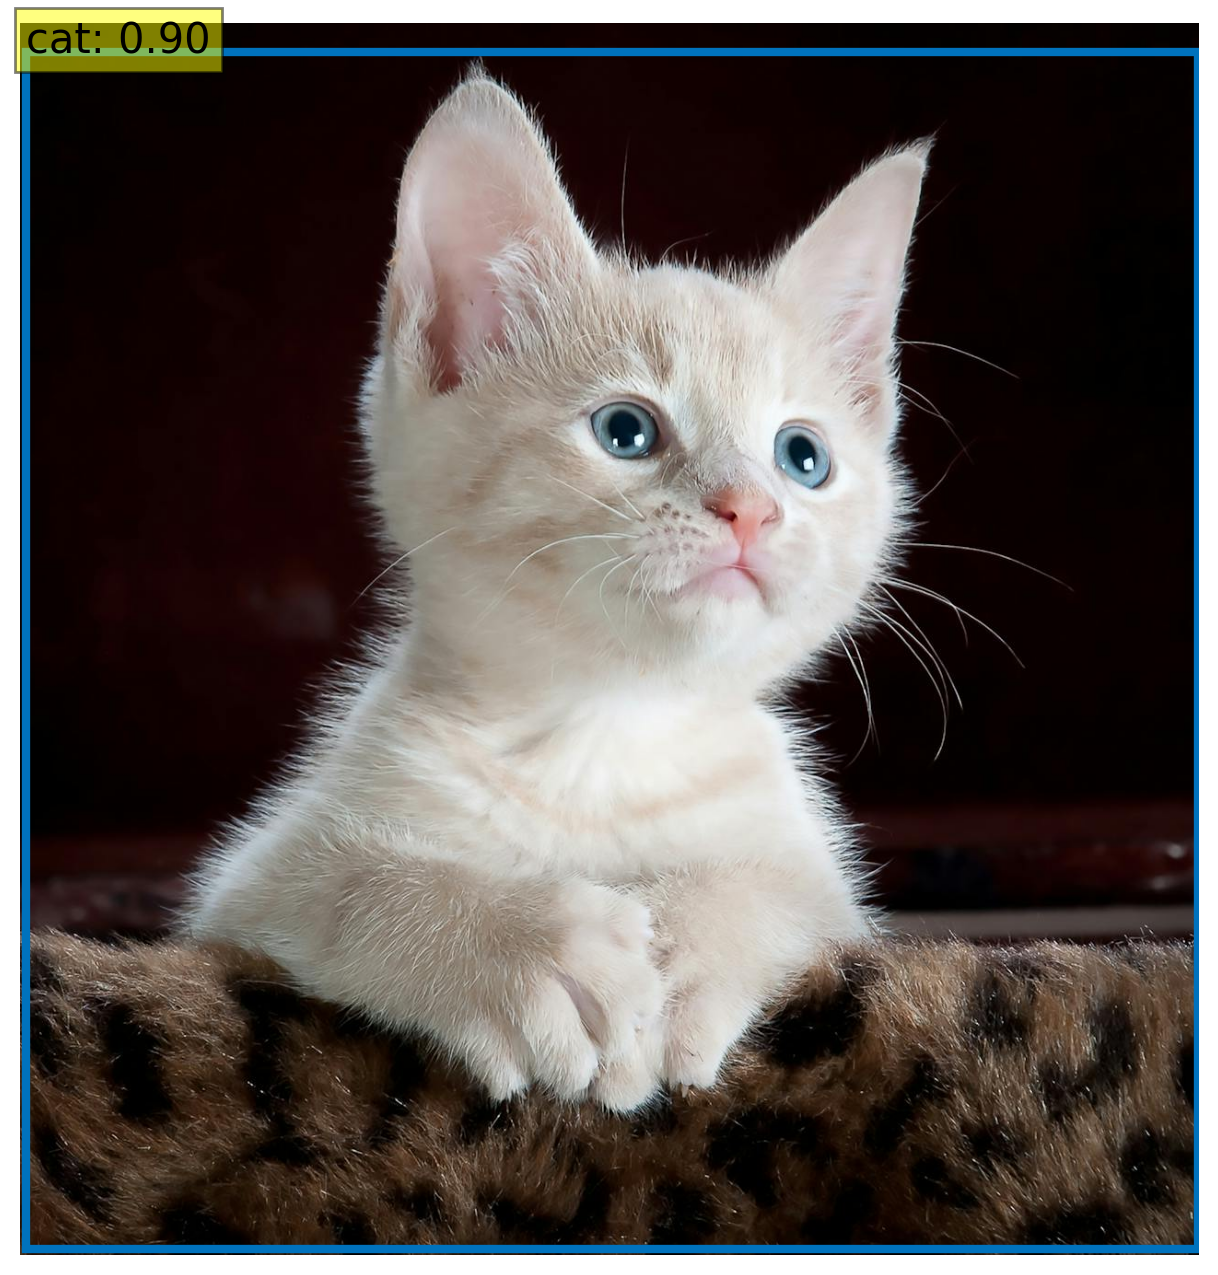

In [27]:
im = Image.open(r'C:\Users\sirom\Desktop\vision-ws\detr-demo\images\cat.jpg')
 
# mean-std normalize the input image (batch-size: 1)
img = transform(im).unsqueeze(0)
 
# Move to device (GPU for faster inference)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
img = img.to(device)
 
# run the model on the input image
outputs = model(img)
 
# keep only predictions with 0.5 confidence or higher
probas = outputs['pred_logits'].softmax(-1)[0, :, :-1]
keep = probas.max(-1).values > 0.8
 
# convert boxes from [0; 1] to image scales
bboxes_scaled = rescale_bboxes(outputs['pred_boxes'][0, keep].cpu(), im.size)
 
# plot the results
plot_results(im, probas[keep].cpu(), bboxes_scaled)